In [21]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping 

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [22]:
x = tf.random.normal((100000, 30))
y = tf.random.uniform((100000,1), minval=0, maxval=3, dtype=tf.int32)

In [23]:
print(x.shape)
print(y.shape)
print()
print(x)
print()
print(y)

(100000, 30)
(100000, 1)

tf.Tensor(
[[ 0.68890566 -1.3571823  -0.5092392  ...  0.67143095 -0.46924087
  -0.6955304 ]
 [ 0.2577977  -0.90400827  1.9448254  ... -0.7780506   0.9848185
   0.7673346 ]
 [-0.15573418 -0.40904996 -0.9094955  ... -0.32917657  0.32243782
   0.7435089 ]
 ...
 [-1.6490412   0.7530494   1.2142689  ...  2.1227345  -0.49083975
  -0.40655756]
 [ 2.2583852   1.6215596   1.3590969  ... -0.82597464  1.2307606
  -0.2553612 ]
 [-1.4976081   0.717577   -1.4596457  ... -0.6751726  -0.7690346
   1.7583113 ]], shape=(100000, 30), dtype=float32)

tf.Tensor(
[[0]
 [1]
 [2]
 ...
 [2]
 [1]
 [1]], shape=(100000, 1), dtype=int32)


In [24]:
x = np.array(x).astype('float32') / 255
y = np.array(y)

In [25]:
from sklearn.model_selection import train_test_split as ttt

In [26]:
x_train, x_test, y_train, y_test = ttt(x,y, random_state=42, test_size=0.3)

print(x_train.shape)
print(x_test.shape)

(70000, 30)
(30000, 30)


In [27]:
temp = pd.Series(y_train[:,0])
np.sort(temp.unique())

array([0, 1, 2], dtype=int32)

In [28]:
import optuna

In [ ]:
def my_model(trial):
    lr = trial.suggest_float('lr', 1e-8, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1,15)
    
    regularizer = trial.suggest_categorical('regularizer', ['l1','l2'])
    reg_rate = trial.suggest_float('lr', 1e-8, 1e-2, log=True)
    if regularizer == 'l1':
        chosen_regularizer = regularizers.l1(reg_rate)
    else:
        chosen_regularizer = regularizers.l2(reg_rate)


    model = keras.Sequential([
        keras.Input(shape=(30,))
    ])

    for i in range(n_layers):
        neurons = trial.suggest_int(f'neurons_{i}', 1,200, step=16)
        activation_fn = trial.suggest_categorical(f'activation_fn_{i}', ['relu', 'leaky_relu', 'elu', 'tanh'])
        initializer = trial.suggest_categorical(f'initializer_{i}', ['he_normal', 'glorot_normal'])
        dropouts = trial.suggest_float(f'dropouts_{i}', 0.0, 0.4, step=0.1)
        
        model.add(layers.Dense(neurons, activation=activation_fn, kernel_initializer=initializer, kernel_regularizer=chosen_regularizer))
        
        if dropouts > 0.0:
            model.add(layers.Dropout(dropouts))

    # output layer
    model.add(layers.Dense(4, activation='softmax'))


    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'nadam'])
    
    if optimizer_name == 'adam':
        chosen_optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        momentum = trial.suggest_float('momentum', 0.1,0.7, step=0.1)
        chosen_optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum) 
    elif optimizer_name == 'rmsprop':
        chosen_optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        chosen_optimizer = keras.optimizers.Nadam(learning_rate=lr)

    

    model.compile(
        loss = keras.losses.SparseCategoricalCrossentropy(),
        optimizer = chosen_optimizer,
        metrics = ['accuracy']
    )

    early_stop = EarlyStopping(
        patience = 3,
        monitor = 'val_loss',
        restore_best_weights = True,
        verbose = 1
    )
    
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        verbose = 1,
        epochs = 10,
        validation_split = 0.2,
        batch_size = 128
    )


    trial.set_user_attr('training_loss', history.history['loss'])
    trial.set_user_attr('training_accuracy', history.history['accuracy'])
    trial.set_user_attr('validation_loss', history.history['val_loss'])
    trial.set_user_attr('validation_accuracy', history.history['val_accuracy'])


    model.save(f"model_trial_{trial.number}.keras")

    best_accuracy = max(history.history['val_accuracy'])

    return best_accuracy
    

In [30]:
study = optuna.create_study(direction='maximize')
study.optimize(my_model, n_trials=5)

[I 2026-09-24 08:20:09,077] A new study created in memory with name: no-name-4e1e6a4f-632c-4f15-b39c-3df2775d5b38


Epoch 1/10


/tmp/ipykernel_58/4025354444.py:18: UserWarning: The distribution is specified by [1, 200] and step=16, but the range is not divisible by `step`. It will be replaced with [1, 193].
  neurons = trial.suggest_int(f'neurons_{i}', 1,200, step=16)


438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3315 - loss: 1.2131 - val_accuracy: 0.3240 - val_loss: 1.1591
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3347 - loss: 1.1500 - val_accuracy: 0.3322 - val_loss: 1.1375
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3329 - loss: 1.1331 - val_accuracy: 0.3240 - val_loss: 1.1263
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3363 - loss: 1.1229 - val_accuracy: 0.3438 - val_loss: 1.1167
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3330 - loss: 1.1164 - val_accuracy: 0.3438 - val_loss: 1.1117
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3349 - loss: 1.1117 - val_accuracy: 0.3322 - val_loss: 1.1099
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3312 - loss: 1.1088 - val_accuracy: 0.3438 - val_loss: 1.1060
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3340 - loss: 1.1068 - val_accuracy: 0.3240 - val

[I 2026-09-24 08:20:29,802] Trial 0 finished with value: 0.34378570318222046 and parameters: {'lr': 0.00026773223862538905, 'n_layers': 3, 'regularizer': 'l2', 'neurons_0': 33, 'activation_fn_0': 'relu', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.4, 'neurons_1': 97, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'he_normal', 'dropouts_1': 0.1, 'neurons_2': 145, 'activation_fn_2': 'elu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.2, 'optimizer': 'nadam'}. Best is trial 0 with value: 0.34378570318222046.


...

[I 2026-09-24 08:21:28,615] Trial 2 finished with value: 0.3240000009536743 and parameters: {'lr': 4.9775521171325894e-05, 'n_layers': 3, 'regularizer': 'l1', 'neurons_0': 65, 'activation_fn_0': 'elu', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.1, 'neurons_1': 81, 'activation_fn_1': 'relu', 'initializer_1': 'glorot_normal', 'dropouts_1': 0.1, 'neurons_2': 17, 'activation_fn_2': 'relu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.1, 'optimizer': 'rmsprop'}. Best is trial 0 with value: 0.34378570318222046.


Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.3292 - loss: 1.3864 - val_accuracy: 0.3322 - val_loss: 1.3863
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3334 - loss: 1.3863 - val_accuracy: 0.3322 - val_loss: 1.3862
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3333 - loss: 1.3862 - val_accuracy: 0.3322 - val_loss: 1.3861
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3336 - loss: 1.3860 - val_accuracy: 0.3322 - val_loss: 1.3860
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3346 - loss: 1.3859 - val_accuracy: 0.3322 - val_loss: 1.3858
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3311 - loss: 1.3858 - val_accuracy: 0.3322 - val_loss: 1.3857
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3366 - loss: 1.3856 - val_accuracy: 0.3322 - val_loss: 1.3856
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3384 - loss: 1.3855 - val_accuracy: 

[I 2026-09-24 08:22:06,543] Trial 3 finished with value: 0.3322142958641052 and parameters: {'lr': 1.3094178459448641e-07, 'n_layers': 11, 'regularizer': 'l2', 'neurons_0': 1, 'activation_fn_0': 'elu', 'initializer_0': 'he_normal', 'dropouts_0': 0.2, 'neurons_1': 161, 'activation_fn_1': 'relu', 'initializer_1': 'glorot_normal', 'dropouts_1': 0.30000000000000004, 'neurons_2': 81, 'activation_fn_2': 'tanh', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.1, 'neurons_3': 1, 'activation_fn_3': 'tanh', 'initializer_3': 'he_normal', 'dropouts_3': 0.2, 'neurons_4': 177, 'activation_fn_4': 'relu', 'initializer_4': 'he_normal', 'dropouts_4': 0.0, 'neurons_5': 49, 'activation_fn_5': 'relu', 'initializer_5': 'he_normal', 'dropouts_5': 0.4, 'neurons_6': 97, 'activation_fn_6': 'relu', 'initializer_6': 'he_normal', 'dropouts_6': 0.1, 'neurons_7': 177, 'activation_fn_7': 'leaky_relu', 'initializer_7': 'glorot_normal', 'dropouts_7': 0.1, 'neurons_8': 177, 'activation_fn_8': 'relu', 'initializer_8': 

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.3309 - loss: 1.4262 - val_accuracy: 0.3438 - val_loss: 1.4263
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3323 - loss: 1.4251 - val_accuracy: 0.3438 - val_loss: 1.4250
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3347 - loss: 1.4239 - val_accuracy: 0.3438 - val_loss: 1.4235
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3339 - loss: 1.4225 - val_accuracy: 0.3438 - val_loss: 1.4220
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3355 - loss: 1.4211 - val_accuracy: 0.3438 - val_loss: 1.4204
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3330 - loss: 1.4197 - val_accuracy: 0.3438 - val_loss: 1.4188
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3351 - loss: 1.4182 - val_accuracy: 0.3438 - val_loss: 1.4172
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3326 - loss: 1.4168 - val_accuracy: 

[I 2026-09-24 08:22:46,267] Trial 4 finished with value: 0.34378570318222046 and parameters: {'lr': 4.16637165258388e-06, 'n_layers': 14, 'regularizer': 'l1', 'neurons_0': 49, 'activation_fn_0': 'elu', 'initializer_0': 'he_normal', 'dropouts_0': 0.1, 'neurons_1': 65, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'glorot_normal', 'dropouts_1': 0.1, 'neurons_2': 193, 'activation_fn_2': 'leaky_relu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.2, 'neurons_3': 65, 'activation_fn_3': 'elu', 'initializer_3': 'he_normal', 'dropouts_3': 0.4, 'neurons_4': 17, 'activation_fn_4': 'relu', 'initializer_4': 'he_normal', 'dropouts_4': 0.0, 'neurons_5': 33, 'activation_fn_5': 'leaky_relu', 'initializer_5': 'glorot_normal', 'dropouts_5': 0.2, 'neurons_6': 113, 'activation_fn_6': 'relu', 'initializer_6': 'he_normal', 'dropouts_6': 0.4, 'neurons_7': 177, 'activation_fn_7': 'relu', 'initializer_7': 'glorot_normal', 'dropouts_7': 0.2, 'neurons_8': 129, 'activation_fn_8': 'elu', 'initializer_8': '

In [32]:
print(study.best_params)
print()
print(study.best_trial)

{'lr': 0.00026773223862538905, 'n_layers': 3, 'regularizer': 'l2', 'neurons_0': 33, 'activation_fn_0': 'relu', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.4, 'neurons_1': 97, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'he_normal', 'dropouts_1': 0.1, 'neurons_2': 145, 'activation_fn_2': 'elu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.2, 'optimizer': 'nadam'}

FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.34378570318222046], datetime_start=datetime.datetime(2026, 9, 24, 8, 20, 9, 78511), datetime_complete=datetime.datetime(2026, 9, 24, 8, 20, 29, 802091), params={'lr': 0.00026773223862538905, 'n_layers': 3, 'regularizer': 'l2', 'neurons_0': 33, 'activation_fn_0': 'relu', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.4, 'neurons_1': 97, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'he_normal', 'dropouts_1': 0.1, 'neurons_2': 145, 'activation_fn_2': 'elu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.2, 'optimizer': 'nadam'}, user_attrs

In [38]:
best_trial = study.best_trial

training_loss = best_trial.user_attrs['training_loss']
training_accuracy = best_trial.user_attrs['training_accuracy']
val_loss = best_trial.user_attrs['validation_loss']
val_accuracy = best_trial.user_attrs['validation_accuracy']


In [39]:
print(training_accuracy)
print(training_loss)
print(val_accuracy)
print(val_loss)

[0.33149999380111694, 0.33473214507102966, 0.33289286494255066, 0.3363214433193207, 0.3330000042915344, 0.33492857217788696, 0.33123213052749634, 0.3339642882347107, 0.3301607072353363, 0.33485713601112366]
[1.2130703926086426, 1.1500301361083984, 1.1331101655960083, 1.122850775718689, 1.1163702011108398, 1.1117302179336548, 1.1087995767593384, 1.106754183769226, 1.1048519611358643, 1.103467583656311]
[0.3240000009536743, 0.3322142958641052, 0.3240000009536743, 0.34378570318222046, 0.34378570318222046, 0.3322142958641052, 0.34378570318222046, 0.3240000009536743, 0.3240000009536743, 0.3240000009536743]
[1.1591123342514038, 1.1375023126602173, 1.1262519359588623, 1.1167494058609009, 1.111732006072998, 1.1099176406860352, 1.1060222387313843, 1.105069637298584, 1.1033363342285156, 1.1022474765777588]


In [40]:
import matplotlib.pyplot as plt

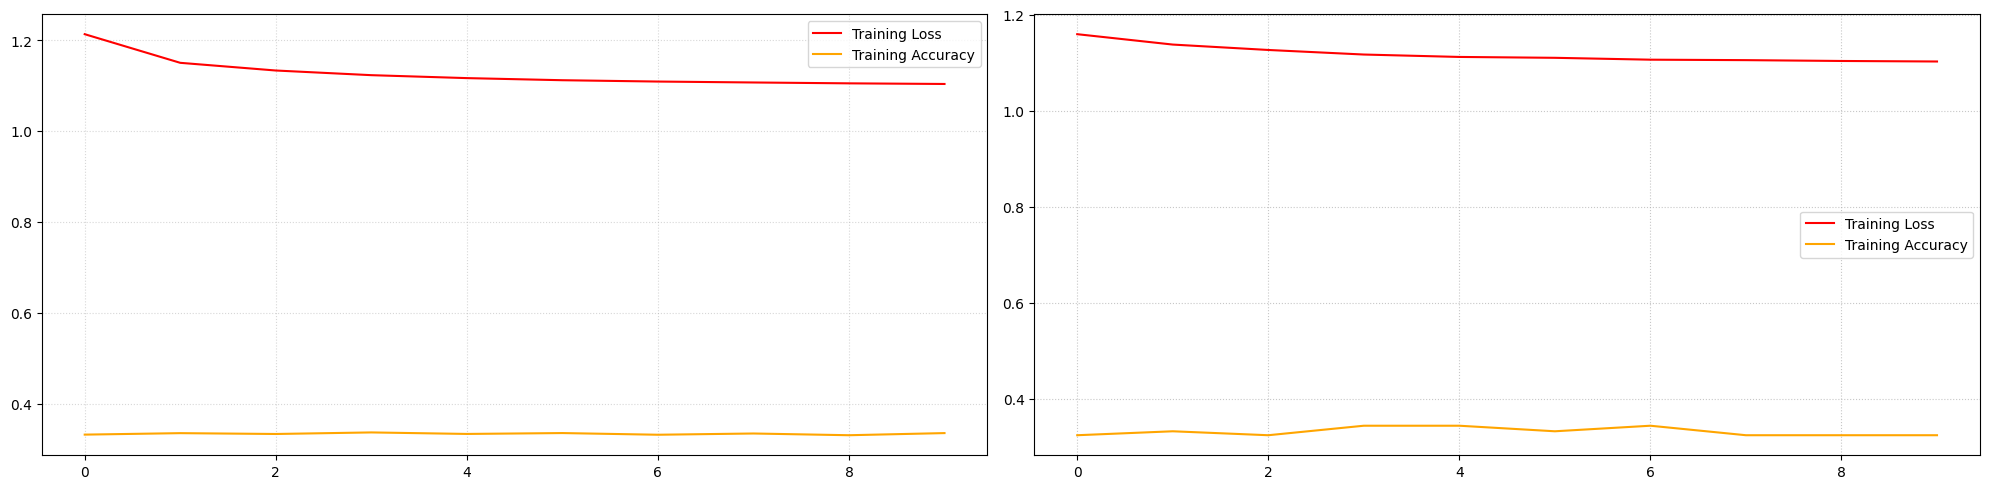

In [46]:
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.plot(training_loss, label='Training Loss', color='red')
plt.plot(training_accuracy, label='Training Accuracy', color='orange')
plt.legend()
plt.grid(True, alpha=0.5, linestyle=':')

plt.subplot(122)
plt.plot(val_loss, label='Training Loss', color='red')
plt.plot(val_accuracy, label='Training Accuracy', color='orange')
plt.legend()
plt.grid(True, alpha=0.7, linestyle=':')

plt.tight_layout()
plt.show()


In [48]:
print("=" * 50)

print(f"Best Validation Loss: {study.best_value:.4f}")
for i,j in study.best_params.items():
    print(f"    {i} : {j}")


print("=" * 50)

Best Validation Loss: 0.3438
    lr : 0.00026773223862538905
    n_layers : 3
    regularizer : l2
    neurons_0 : 33
    activation_fn_0 : relu
    initializer_0 : glorot_normal
    dropouts_0 : 0.4
    neurons_1 : 97
    activation_fn_1 : leaky_relu
    initializer_1 : he_normal
    dropouts_1 : 0.1
    neurons_2 : 145
    activation_fn_2 : elu
    initializer_2 : glorot_normal
    dropouts_2 : 0.2
    optimizer : nadam


In [49]:
best_trial_num = study.best_trial.number
model = keras.models.load_model(f"model_trial_{best_trial_num}.keras")

y_pred = model.predict(x_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [53]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

Accuracy: 0.33103333333333335
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10046
           1       0.00      0.00      0.00     10023
           2       0.33      1.00      0.50      9931

    accuracy                           0.33     30000
   macro avg       0.11      0.33      0.17     30000
weighted avg       0.11      0.33      0.16     30000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
